Cleaned dataset loaded successfully!
Dataset shape: (60, 17)
Column names:
['customer_id', 'first_name', 'gender', 'age', 'city', 'province', 'signup_date', 'membership_tier', 'purchase_count', 'avg_order_value', 'total_spending', 'last_purchase_days', 'payment_method', 'device', 'discount_used', 'returned_items', 'satisfaction_score']

Data types:
customer_id             int64
first_name                str
gender                    str
age                     int64
city                      str
province                  str
signup_date               str
membership_tier           str
purchase_count          int64
avg_order_value       float64
total_spending        float64
last_purchase_days      int64
payment_method            str
device                    str
discount_used             str
returned_items        float64
satisfaction_score      int64
dtype: object
Analysis dataset shape: (60, 17)
Customer Profile Summary


Number of unique customers                60
Mean age                                43.7
Median age                              45.0
Most common gender                         M
Most common membership tier             Gold
Most common device                   Android
Most common payment method     Online Wallet
Name: Value, dtype: object

Customer Count by Age Group


,Customer Count
age_group,
Under 25,7
25-34,11
35-44,10
45-54,15
55-64,16
65 and above,1


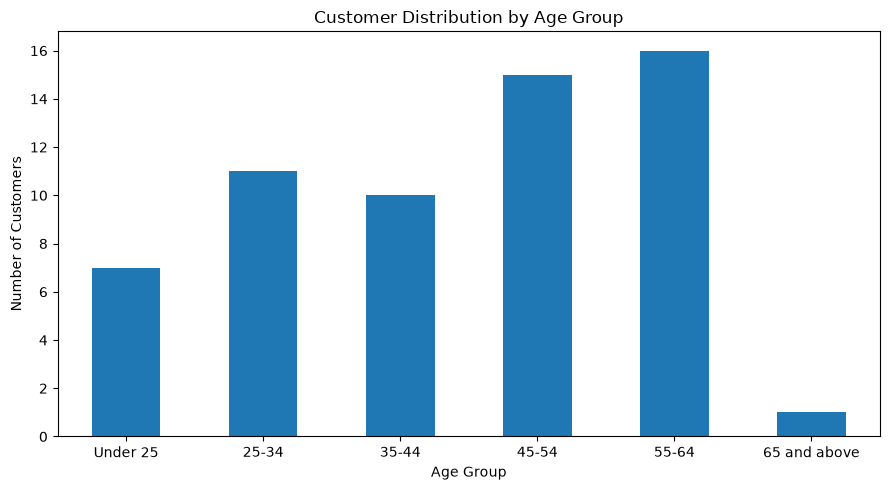

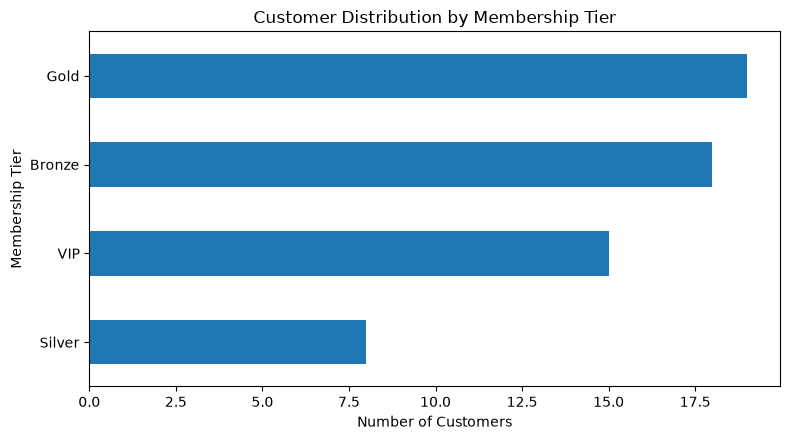

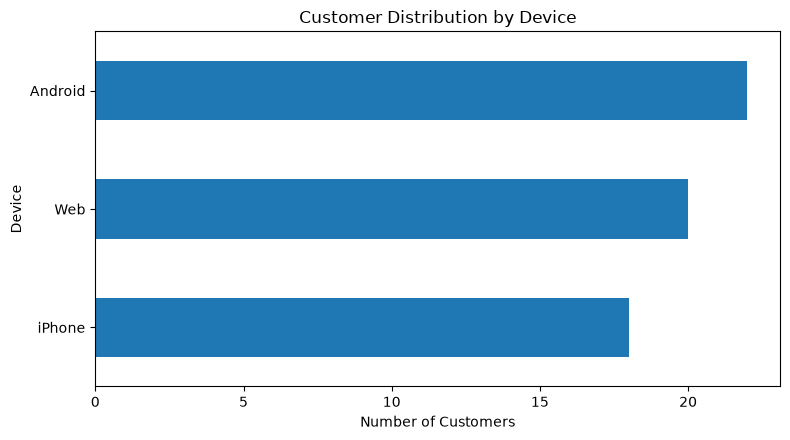

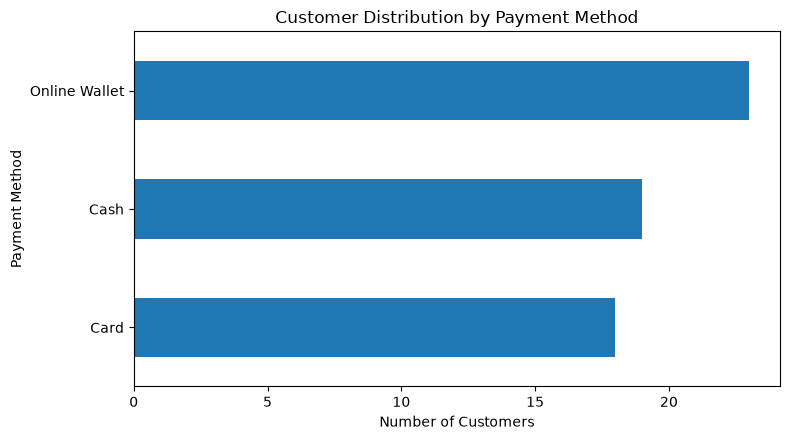

In [13]:
# %% [markdown]
# Project 02 — Customer Analytics
# Question 1: Understanding Customer Characteristics
#
# This section analyzes the main demographic and behavioral
# characteristics of customers, including:
# - Age
# - Gender
# - Membership tier
# - Device
# - Payment method

# %%
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# %%
# Load the cleaned dataset

file_path = "cleaned_dataset.xlsx"

df = pd.read_excel(file_path)

print("Cleaned dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")

# %%
# Display basic information about the dataset

print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

# %%
# Create a copy for analysis

analysis_df = df.copy()

# Remove rows with missing values in the variables
# required for this analysis

analysis_df = analysis_df.dropna(
    subset=[
        "gender",
        "age",
        "membership_tier",
        "device",
        "payment_method"
    ]
).copy()

print(f"Analysis dataset shape: {analysis_df.shape}")

# %%
# Create age groups

age_bins = [0, 24, 34, 44, 54, 64, np.inf]

age_labels = [
    "Under 25",
    "25-34",
    "35-44",
    "45-54",
    "55-64",
    "65 and above"
]

analysis_df["age_group"] = pd.cut(
    analysis_df["age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

# %%
# Calculate customer profile summary

profile_summary = {
    "Number of unique customers": analysis_df["customer_id"].nunique(),
    "Mean age": analysis_df["age"].mean(),
    "Median age": analysis_df["age"].median(),
    "Most common gender": analysis_df["gender"].mode().iloc[0],
    "Most common membership tier": analysis_df["membership_tier"].mode().iloc[0],
    "Most common device": analysis_df["device"].mode().iloc[0],
    "Most common payment method": analysis_df["payment_method"].mode().iloc[0]
}

profile_table = pd.Series(
    profile_summary,
    name="Value"
)

print("Customer Profile Summary")
print("=" * 50)

display(profile_table)

# %%
# Display the number of customers in each age group

age_counts = (
    analysis_df["age_group"]
    .value_counts(sort=False)
)

print("Customer Count by Age Group")
print("=" * 50)

display(
    age_counts.to_frame(
        name="Customer Count"
    )
)

# %%
# Plot customer distribution by age group

plt.figure(figsize=(9, 5))

age_counts.plot(
    kind="bar"
)

plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# %%
# Plot membership tier distribution

membership_counts = (
    analysis_df["membership_tier"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(8, 4.5))

membership_counts.plot(
    kind="barh"
)

plt.title("Customer Distribution by Membership Tier")
plt.xlabel("Number of Customers")
plt.ylabel("Membership Tier")

plt.tight_layout()
plt.show()

# %%
# Plot device distribution

device_counts = (
    analysis_df["device"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(8, 4.5))

device_counts.plot(
    kind="barh"
)

plt.title("Customer Distribution by Device")
plt.xlabel("Number of Customers")
plt.ylabel("Device")

plt.tight_layout()
plt.show()

# %%
# Plot payment method distribution

payment_counts = (
    analysis_df["payment_method"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(8, 4.5))

payment_counts.plot(
    kind="barh"
)

plt.title("Customer Distribution by Payment Method")
plt.xlabel("Number of Customers")
plt.ylabel("Payment Method")

plt.tight_layout()
plt.show()

Rows available for location analysis: 60
Number of cities with at least 3 customers: 8
Top 10 cities by total customer spending:


,province,city,customer_count,total_revenue,avg_customer_spending,avg_purchase_count,avg_order_value,avg_satisfaction
5,Khorasan,Mashhad,11,43197.58,3927.052727,22.636364,210.508182,2.909091
1,East Azerbaijan,Tabriz,12,36192.49,3016.040833,15.750000,238.901667,3.000000
0,Alborz,Karaj,7,26189.81,3741.401429,16.000000,211.440000,2.857143
6,Khuzestan,Ahvaz,8,23384.78,2923.097500,13.875000,216.531250,3.500000
4,Isfahan,Isfahan,5,21975.32,4395.064000,19.800000,212.680000,4.400000
2,Fars,Shiraz,6,20715.92,3452.653333,16.333333,180.983333,2.000000
3,Gilan,Rasht,5,15168.54,3033.708000,16.400000,241.554000,2.600000
7,Tehran,Tehran,6,15161.29,2526.881667,17.166667,172.930000,2.666667


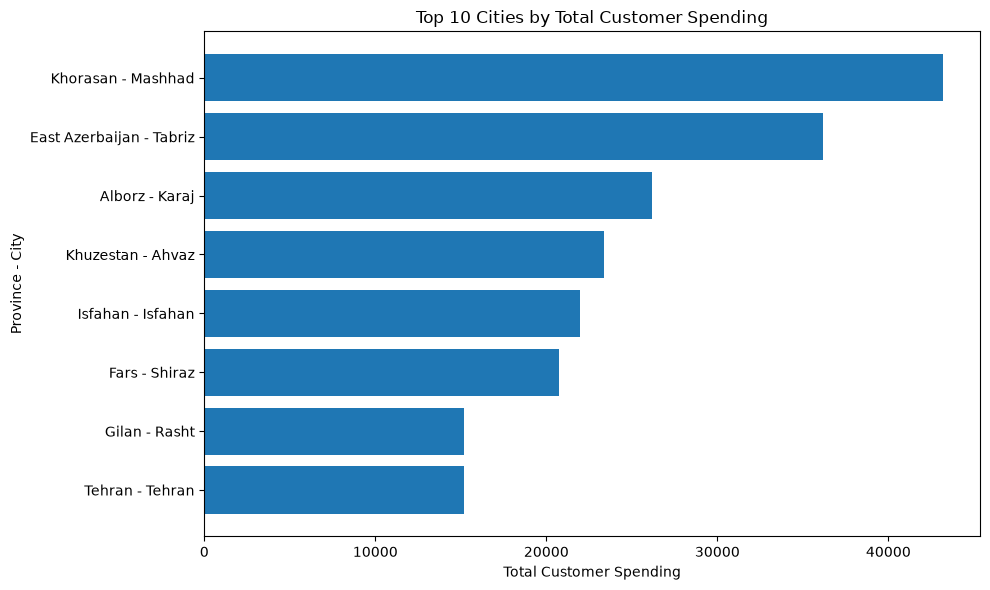

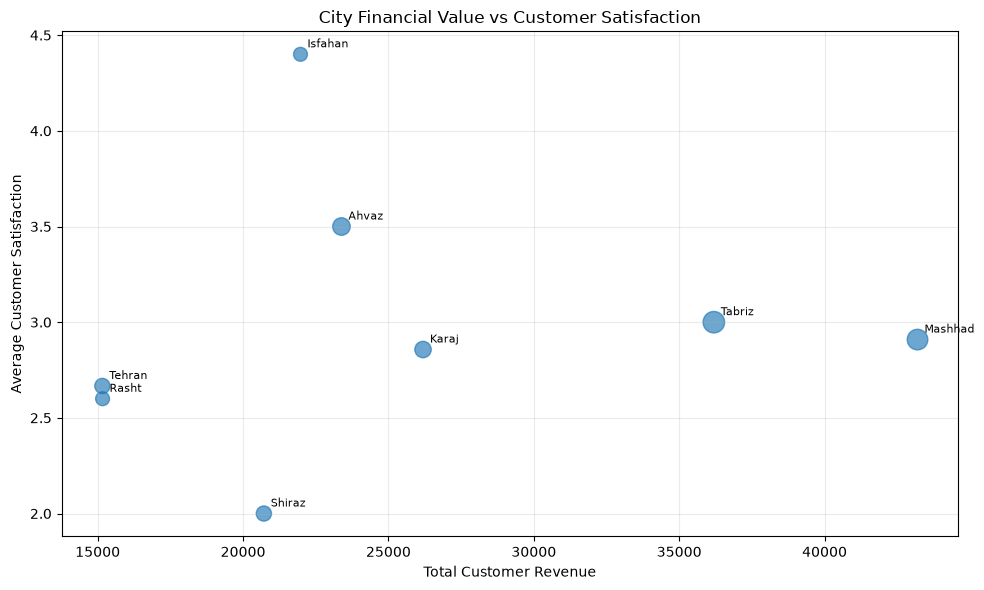

Recommended city for advertising:


,province,city,customer_count,total_revenue,avg_customer_spending,avg_purchase_count,avg_order_value,avg_satisfaction
5,Khorasan,Mashhad,11,43197.58,3927.052727,22.636364,210.508182,2.909091


In [14]:
# ============================================
# Question 2: Selecting the Best Region for Advertising
# ============================================

# ============================================
# 2. Select Required Columns and Remove Missing Values
# ============================================

location_df = df.dropna(
    subset=[
        "province",
        "city",
        "customer_id",
        "total_spending",
        "satisfaction_score"
    ]
).copy()

print(f"Rows available for location analysis: {len(location_df)}")


# ============================================
# 3. Calculate City-Level Summary
# ============================================

city_summary = (
    location_df
    .groupby(
        ["province", "city"],
        as_index=False
    )
    .agg(
        customer_count=("customer_id", "nunique"),
        total_revenue=("total_spending", "sum"),
        avg_customer_spending=("total_spending", "mean"),
        avg_purchase_count=("purchase_count", "mean"),
        avg_order_value=("avg_order_value", "mean"),
        avg_satisfaction=("satisfaction_score", "mean")
    )
)


# ============================================
# 4. Keep Cities with at Least 3 Customers
# ============================================

city_summary = city_summary[
    city_summary["customer_count"] >= 3
].copy()

print(
    f"Number of cities with at least 3 customers: "
    f"{len(city_summary)}"
)


# ============================================
# 5. Find the Top 10 Cities by Total Revenue
# ============================================

top_cities = (
    city_summary
    .nlargest(10, "total_revenue")
    .sort_values("total_revenue")
)

print("Top 10 cities by total customer spending:")

display(
    top_cities
    .sort_values(
        "total_revenue",
        ascending=False
    )
)


# ============================================
# 6. Plot Top 10 Cities by Total Revenue
# ============================================

labels = (
    top_cities["province"]
    + " - "
    + top_cities["city"]
)

plt.figure(figsize=(10, 6))

plt.barh(
    labels,
    top_cities["total_revenue"]
)

plt.title(
    "Top 10 Cities by Total Customer Spending"
)

plt.xlabel(
    "Total Customer Spending"
)

plt.ylabel(
    "Province - City"
)

plt.tight_layout()
plt.show()


# ============================================
# 7. Analyze Financial Value vs Customer Satisfaction
# ============================================

plt.figure(figsize=(10, 6))

plt.scatter(
    city_summary["total_revenue"],
    city_summary["avg_satisfaction"],
    s=city_summary["customer_count"] * 20,
    alpha=0.65
)

for _, row in city_summary.iterrows():
    plt.annotate(
        row["city"],
        (row["total_revenue"], row["avg_satisfaction"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.title("City Financial Value vs Customer Satisfaction")
plt.xlabel("Total Customer Revenue")
plt.ylabel("Average Customer Satisfaction")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


# ============================================
# 8. Recommend the Best City for Advertising
# ============================================

recommended_city = (
    city_summary
    .sort_values(
        [
            "total_revenue",
            "avg_satisfaction",
            "customer_count"
        ],
        ascending=[
            False,
            False,
            False
        ]
    )
    .head(1)
)

print("Recommended city for advertising:")

display(recommended_city)

Number of customers available for loyalty analysis: 60


,customer_id,first_name,membership_tier,purchase_count,total_spending,last_purchase_days,satisfaction_score,loyalty_score
56,1057,Maryam,Bronze,31,13532.74,82,4,0.864535
43,1044,Mina,Gold,33,14354.34,165,2,0.780854
58,1059,Ali,Gold,31,8898.55,224,5,0.710587
8,1009,Kimia,Silver,34,11615.42,232,2,0.685627
3,1004,Sina,Gold,23,6121.45,40,4,0.638459
11,1012,Arash,Gold,27,11731.50,224,2,0.632877
32,1033,Neda,VIP,24,5521.20,112,5,0.630116
13,1014,Reza,VIP,31,3353.89,97,4,0.608058
22,1023,Ali,Bronze,31,3851.44,170,4,0.579858
16,1017,Parsa,VIP,30,3239.40,135,4,0.575701


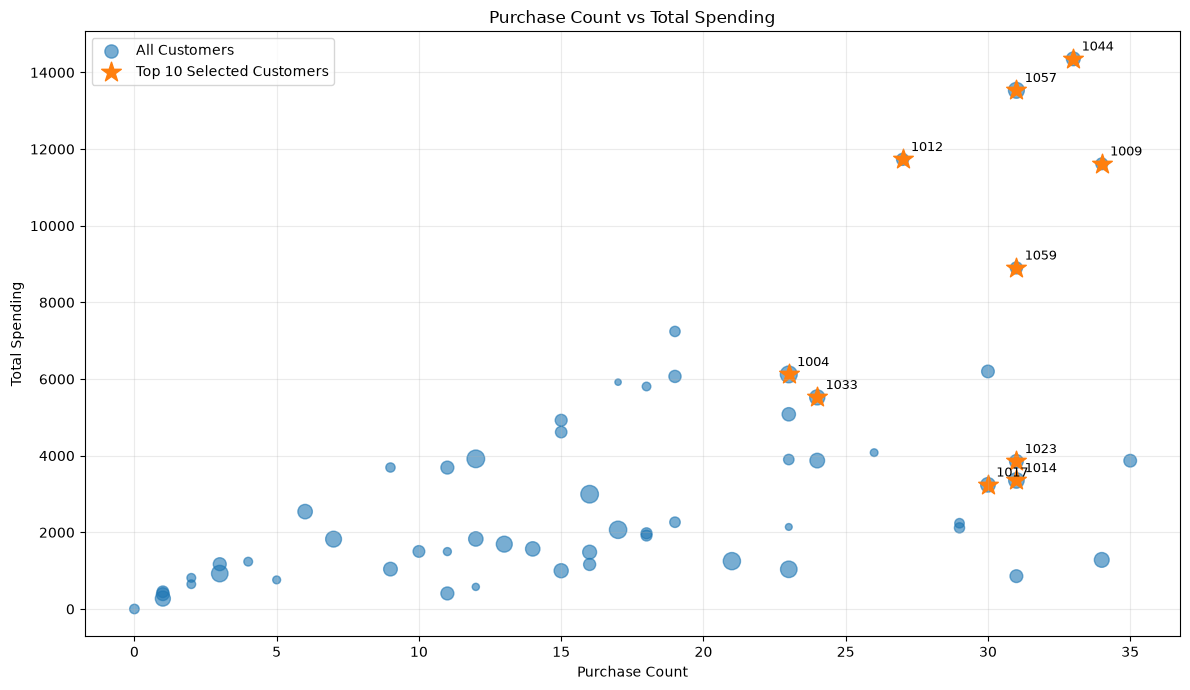

In [15]:
# ============================================
# Question 3: Identifying High-Value and Loyal Customers
# ============================================

# Select the columns required for loyalty analysis
loyalty_df = df.dropna(
    subset=[
        "customer_id",
        "first_name",
        "purchase_count",
        "total_spending",
        "last_purchase_days",
        "satisfaction_score"
    ]
).copy()

print(
    f"Number of customers available for loyalty analysis: "
    f"{len(loyalty_df)}"
)

# ============================================
# 1. Normalize Purchase Count, Total Spending,
#    and Satisfaction Score
# ============================================

for column in [
    "purchase_count",
    "total_spending",
    "satisfaction_score"
]:
    minimum = loyalty_df[column].min()
    maximum = loyalty_df[column].max()

    if maximum == minimum:
        loyalty_df[f"{column}_score"] = 1.0
    else:
        loyalty_df[f"{column}_score"] = (
            loyalty_df[column] - minimum
        ) / (maximum - minimum)

# ============================================
# 2. Calculate Recency Score
# ============================================

recency_min = loyalty_df["last_purchase_days"].min()
recency_max = loyalty_df["last_purchase_days"].max()

if recency_max == recency_min:
    loyalty_df["recency_score"] = 1.0
else:
    loyalty_df["recency_score"] = 1 - (
        (loyalty_df["last_purchase_days"] - recency_min)
        / (recency_max - recency_min)
    )

# ============================================
# 3. Calculate Overall Loyalty Score
# ============================================

loyalty_df["loyalty_score"] = (
    0.35 * loyalty_df["total_spending_score"]
    + 0.30 * loyalty_df["purchase_count_score"]
    + 0.20 * loyalty_df["recency_score"]
    + 0.15 * loyalty_df["satisfaction_score_score"]
)

# ============================================
# 4. Select the Top 10 Customers
# ============================================

top_loyal_customers = (
    loyalty_df
    .nlargest(10, "loyalty_score")
    [[
        "customer_id",
        "first_name",
        "membership_tier",
        "purchase_count",
        "total_spending",
        "last_purchase_days",
        "satisfaction_score",
        "loyalty_score"
    ]]
)

display(top_loyal_customers)

# ============================================
# 5. Visualize Customer Value and Activity
# ============================================

plt.figure(figsize=(12, 7))

# Plot all customers
plt.scatter(
    loyalty_df["purchase_count"],
    loyalty_df["total_spending"],
    s=(loyalty_df["recency_score"] + 0.15) * 140,
    alpha=0.6,
    label="All Customers"
)

# Highlight the top 10 selected customers
plt.scatter(
    top_loyal_customers["purchase_count"],
    top_loyal_customers["total_spending"],
    s=220,
    marker="*",
    label="Top 10 Selected Customers"
)

# Add customer IDs to the selected customers
for _, row in top_loyal_customers.iterrows():
    plt.annotate(
        str(row["customer_id"]),
        (row["purchase_count"], row["total_spending"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9
    )

plt.title("Purchase Count vs Total Spending")
plt.xlabel("Purchase Count")
plt.ylabel("Total Spending")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Risk Thresholds
--------------------------------------------------
High-value spending threshold: 4213.12
Minimum purchase count threshold: 17.00
Inactivity threshold (days): 273.75

High-Value Customers at Risk of Becoming Inactive
----------------------------------------------------------------------


,customer_id,first_name,membership_tier,purchase_count,total_spending,last_purchase_days,satisfaction_score
9,1010,Arash,Silver,19,7241.47,276,1
34,1035,Arash,Bronze,17,5918.21,365,3
52,1053,Sina,Gold,18,5805.54,320,1



Number of high-value customers at risk: 3


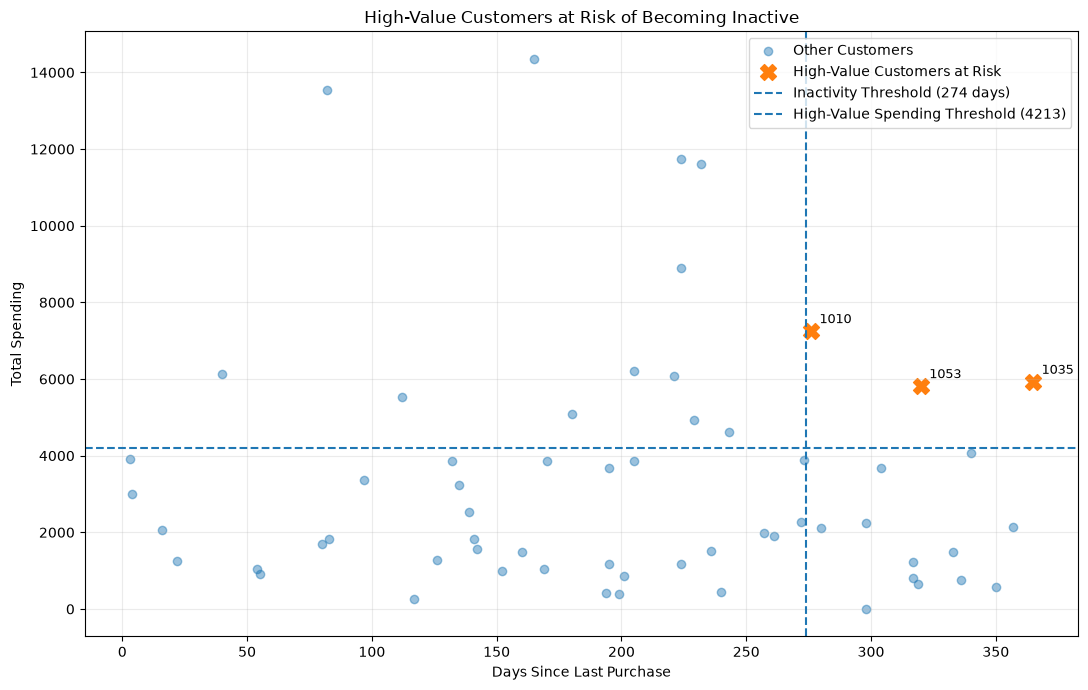

In [16]:
# Question 4 - Identifying High-Value Customers at Risk of Becoming Inactive

risk_df = df.dropna(
    subset=[
        "customer_id",
        "first_name",
        "total_spending",
        "purchase_count",
        "last_purchase_days"
    ]
).copy()


# Define thresholds
spending_threshold = risk_df["total_spending"].quantile(0.75)
purchase_threshold = risk_df["purchase_count"].median()
inactivity_threshold = risk_df["last_purchase_days"].quantile(0.75)


print("Risk Thresholds")
print("-" * 50)
print(f"High-value spending threshold: {spending_threshold:.2f}")
print(f"Minimum purchase count threshold: {purchase_threshold:.2f}")
print(f"Inactivity threshold (days): {inactivity_threshold:.2f}")


# Identify high-value customers at risk
risk_df["at_risk"] = (
    (risk_df["total_spending"] >= spending_threshold)
    & (risk_df["purchase_count"] >= purchase_threshold)
    & (risk_df["last_purchase_days"] >= inactivity_threshold)
)


# Select at-risk customers
at_risk_customers = risk_df.loc[
    risk_df["at_risk"],
    [
        "customer_id",
        "first_name",
        "membership_tier",
        "purchase_count",
        "total_spending",
        "last_purchase_days",
        "satisfaction_score"
    ]
].sort_values(
    ["total_spending", "last_purchase_days"],
    ascending=[False, False]
)


# Display at-risk customers
print("\nHigh-Value Customers at Risk of Becoming Inactive")
print("-" * 70)

display(at_risk_customers)

print(
    f"\nNumber of high-value customers at risk: "
    f"{len(at_risk_customers)}"
)

# Plot high-value customers at risk of becoming inactive

plt.figure(figsize=(11, 7))

# Other customers
plt.scatter(
    risk_df.loc[~risk_df["at_risk"], "last_purchase_days"],
    risk_df.loc[~risk_df["at_risk"], "total_spending"],
    alpha=0.45,
    label="Other Customers"
)


# At-risk customers
plt.scatter(
    risk_df.loc[risk_df["at_risk"], "last_purchase_days"],
    risk_df.loc[risk_df["at_risk"], "total_spending"],
    marker="X",
    s=130,
    label="High-Value Customers at Risk"
)


# Add customer IDs to at-risk customers
for _, row in at_risk_customers.iterrows():
    plt.annotate(
        str(row["customer_id"]),
        (
            row["last_purchase_days"],
            row["total_spending"]
        ),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9
    )


# Add threshold lines
plt.axvline(
    inactivity_threshold,
    linestyle="--",
    label=f"Inactivity Threshold ({inactivity_threshold:.0f} days)"
)

plt.axhline(
    spending_threshold,
    linestyle="--",
    label=f"High-Value Spending Threshold ({spending_threshold:.0f})"
)


plt.title(
    "High-Value Customers at Risk of Becoming Inactive"
)

plt.xlabel(
    "Days Since Last Purchase"
)

plt.ylabel(
    "Total Spending"
)

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

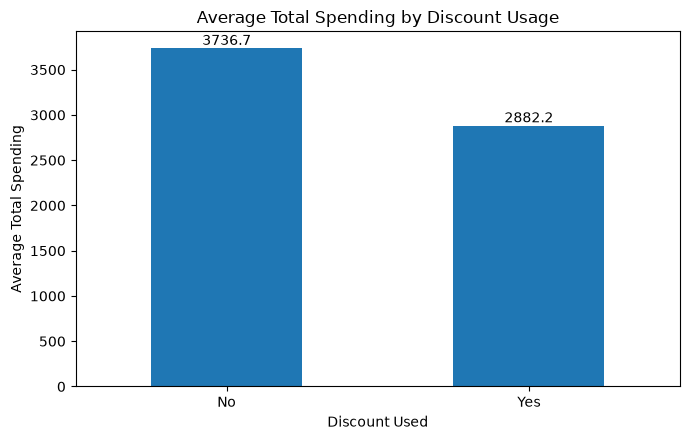

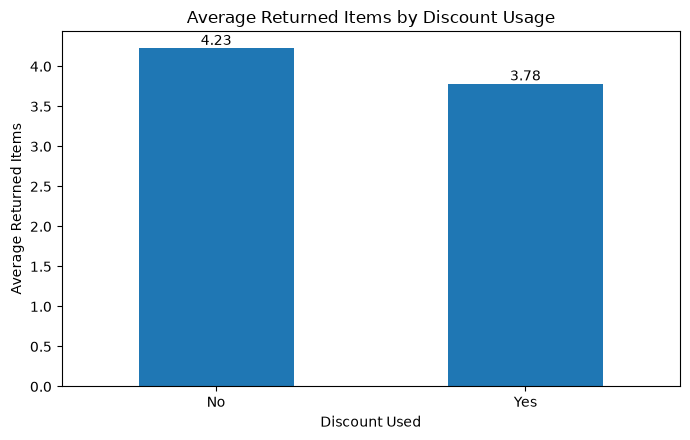

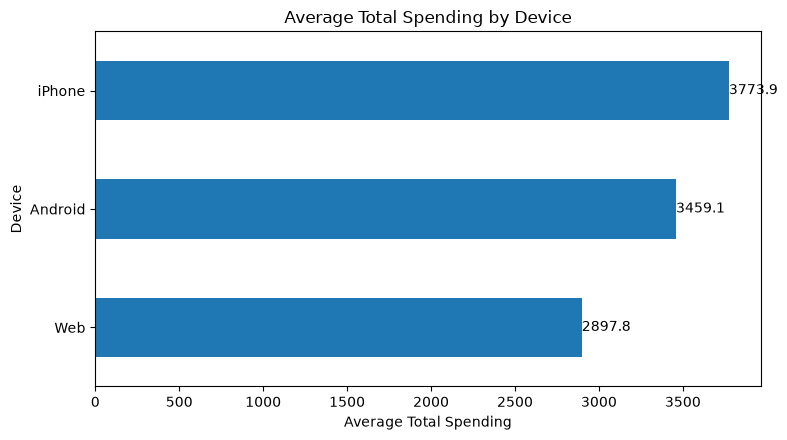

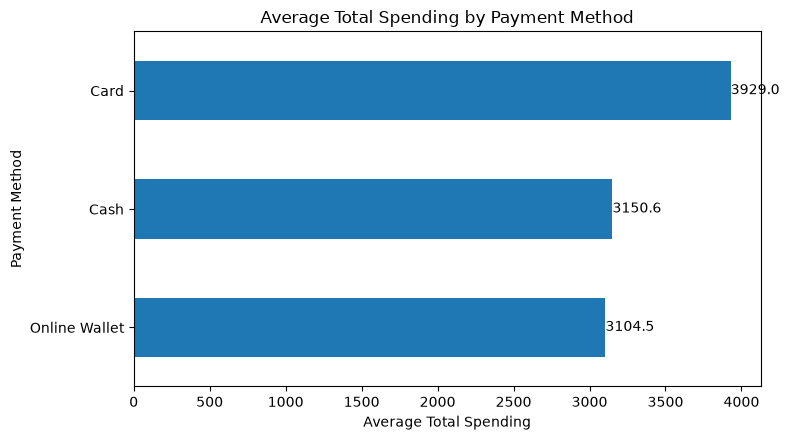

In [17]:
# Question 5: Customer behavior by discount, device, and payment method

# 1. Average total spending by discount usage
discount_spending = (
    df.dropna(subset=["discount_used", "total_spending"])
    .groupby("discount_used")["total_spending"]
    .mean()
)

ax = discount_spending.plot(
    kind="bar",
    figsize=(7, 4.5),
    title="Average Total Spending by Discount Usage"
)

ax.set_xlabel("Discount Used")
ax.set_ylabel("Average Total Spending")
ax.tick_params(axis="x", rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

plt.tight_layout()
plt.show()


# 2. Average returned items by discount usage
discount_returns = (
    df.dropna(subset=["discount_used", "returned_items"])
    .groupby("discount_used")["returned_items"]
    .mean()
)

ax = discount_returns.plot(
    kind="bar",
    figsize=(7, 4.5),
    title="Average Returned Items by Discount Usage"
)

ax.set_xlabel("Discount Used")
ax.set_ylabel("Average Returned Items")
ax.tick_params(axis="x", rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.tight_layout()
plt.show()


# 3. Average total spending by device
device_spending = (
    df.dropna(subset=["device", "total_spending"])
    .groupby("device")["total_spending"]
    .mean()
    .sort_values()
)

ax = device_spending.plot(
    kind="barh",
    figsize=(8, 4.5),
    title="Average Total Spending by Device"
)

ax.set_xlabel("Average Total Spending")
ax.set_ylabel("Device")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

plt.tight_layout()
plt.show()


# 4. Average total spending by payment method
payment_spending = (
    df.dropna(subset=["payment_method", "total_spending"])
    .groupby("payment_method")["total_spending"]
    .mean()
    .sort_values()
)

ax = payment_spending.plot(
    kind="barh",
    figsize=(8, 4.5),
    title="Average Total Spending by Payment Method"
)

ax.set_xlabel("Average Total Spending")
ax.set_ylabel("Payment Method")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

plt.tight_layout()
plt.show()

In [18]:
# Question 6:
# KPI Summary

kpi_summary = pd.Series({
    "Unique Customers": df["customer_id"].nunique(),
    "Total Customer Spending": df["total_spending"].sum(),
    "Average Customer Spending": df["total_spending"].mean(),
    "Average Purchase Count": df["purchase_count"].mean(),
    "Average Satisfaction Score": df["satisfaction_score"].mean(),
    "Total Returned Items": df["returned_items"].sum()
}, name="Value")

display(kpi_summary)

Unique Customers                  60.000000
Total Customer Spending       201985.730000
Average Customer Spending       3366.428833
Average Purchase Count            17.383333
Average Satisfaction Score         2.983333
Total Returned Items             218.000000
Name: Value, dtype: float64

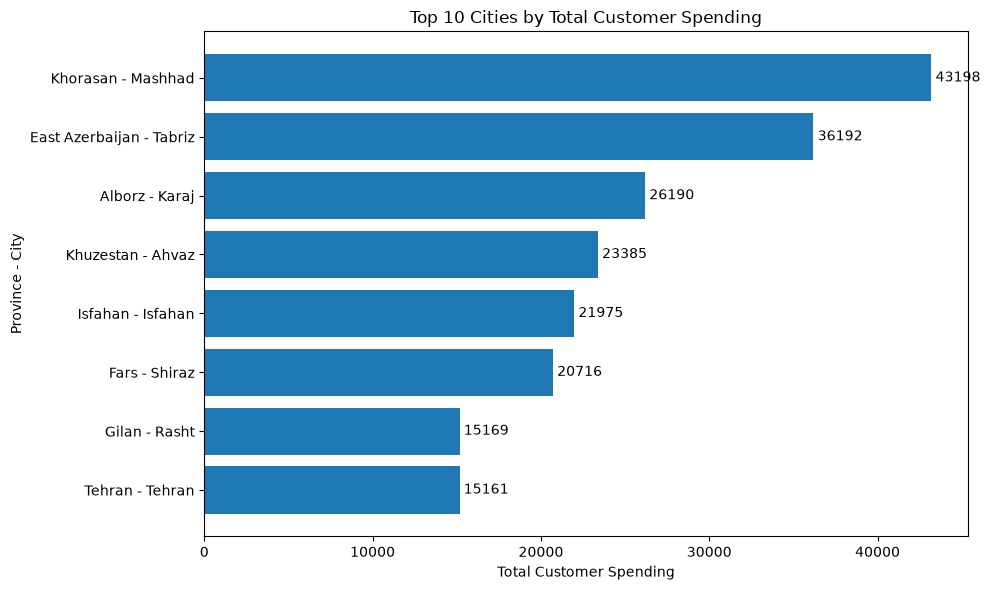

In [19]:
# City-level analysis

location_df = df.dropna(
    subset=[
        "province",
        "city",
        "customer_id",
        "total_spending",
        "satisfaction_score"
    ]
).copy()

city_summary = (
    location_df
    .groupby(["province", "city"], as_index=False)
    .agg(
        customer_count=("customer_id", "nunique"),
        total_revenue=("total_spending", "sum"),
        avg_customer_spending=("total_spending", "mean"),
        avg_purchase_count=("purchase_count", "mean"),
        avg_order_value=("avg_order_value", "mean"),
        avg_satisfaction=("satisfaction_score", "mean")
    )
)

# Keep cities with at least 3 customers
city_summary = city_summary[
    city_summary["customer_count"] >= 3
].copy()

# Top 10 cities by total spending

chart1 = (
    city_summary
    .nlargest(10, "total_revenue")
    .sort_values("total_revenue")
)

chart1_labels = (
    chart1["province"] + " - " + chart1["city"]
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    chart1_labels,
    chart1["total_revenue"]
)

plt.title("Top 10 Cities by Total Customer Spending")
plt.xlabel("Total Customer Spending")
plt.ylabel("Province - City")

# Add value labels
plt.bar_label(
    bars,
    fmt="%.0f",
    padding=3
)

plt.tight_layout()
plt.show()

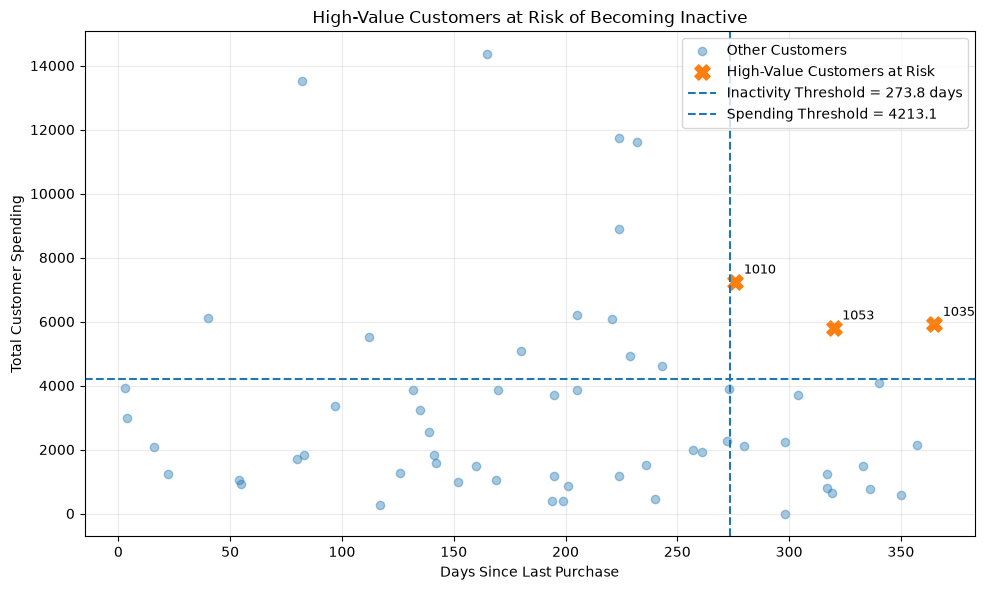

In [20]:
# Identify high-value customers at risk of becoming inactive

risk_df = df.dropna(
    subset=[
        "customer_id",
        "first_name",
        "total_spending",
        "purchase_count",
        "last_purchase_days"
    ]
).copy()

spending_threshold = risk_df["total_spending"].quantile(0.75)
purchase_threshold = risk_df["purchase_count"].median()
inactivity_threshold = risk_df["last_purchase_days"].quantile(0.75)

risk_df["at_risk"] = (
    (risk_df["total_spending"] >= spending_threshold) &
    (risk_df["purchase_count"] >= purchase_threshold) &
    (risk_df["last_purchase_days"] >= inactivity_threshold)
)

at_risk_customers = (
    risk_df[risk_df["at_risk"]]
    .sort_values(
        ["total_spending", "last_purchase_days"],
        ascending=[False, False]
    )
)

# High-value customers at risk

plt.figure(figsize=(10, 6))

# Other customers
plt.scatter(
    risk_df.loc[~risk_df["at_risk"], "last_purchase_days"],
    risk_df.loc[~risk_df["at_risk"], "total_spending"],
    alpha=0.4,
    label="Other Customers"
)

# At-risk customers
at_risk_plot = plt.scatter(
    risk_df.loc[risk_df["at_risk"], "last_purchase_days"],
    risk_df.loc[risk_df["at_risk"], "total_spending"],
    marker="X",
    s=120,
    label="High-Value Customers at Risk"
)

# Add customer IDs as labels
for _, row in risk_df[risk_df["at_risk"]].iterrows():
    plt.annotate(
        str(int(row["customer_id"])),
        (
            row["last_purchase_days"],
            row["total_spending"]
        ),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9
    )

# Threshold lines
plt.axvline(
    inactivity_threshold,
    linestyle="--",
    label=f"Inactivity Threshold = {inactivity_threshold:.1f} days"
)

plt.axhline(
    spending_threshold,
    linestyle="--",
    label=f"Spending Threshold = {spending_threshold:.1f}"
)

plt.title("High-Value Customers at Risk of Becoming Inactive")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Total Customer Spending")

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

,discount_used,customer_count,avg_total_spending
0,No,34,3736.741176
1,Yes,26,2882.174231


,discount_used,customer_count,avg_returned_items
0,No,31,4.225806
1,Yes,23,3.782609


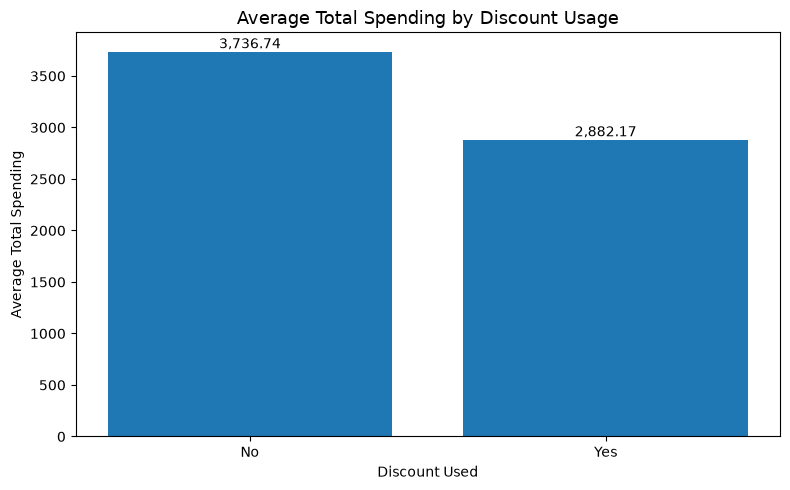

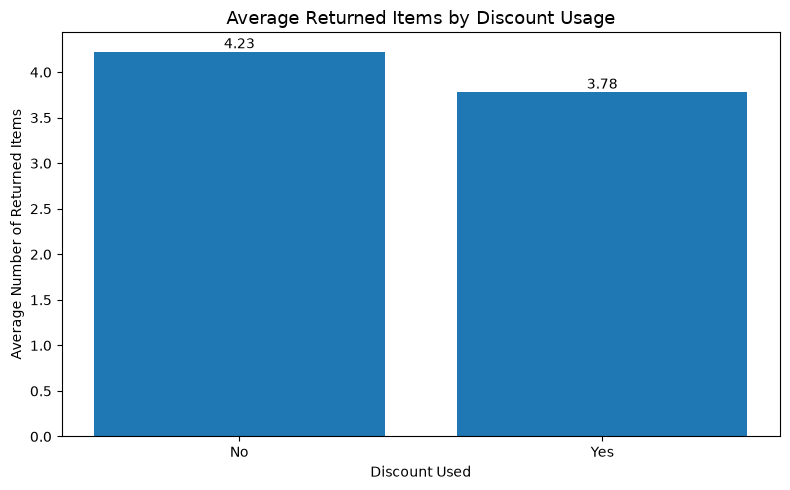

In [21]:
# %%
# Question 5 - Discount Analysis

# Create separate datasets for each analysis.
# We do not delete the original rows.

discount_spending_df = df.dropna(
    subset=["discount_used", "total_spending"]
).copy()

discount_return_df = df.dropna(
    subset=["discount_used", "returned_items"]
).copy()


# %%
# Average Total Spending by Discount Usage

summary_spending = (
    discount_spending_df
    .groupby("discount_used")
    .agg(
        customer_count=("customer_id", "nunique"),
        avg_total_spending=("total_spending", "mean")
    )
    .reset_index()
)

display(summary_spending)


# %%
# Average Returned Items by Discount Usage

summary_return = (
    discount_return_df
    .groupby("discount_used")
    .agg(
        customer_count=("customer_id", "nunique"),
        avg_returned_items=("returned_items", "mean")
    )
    .reset_index()
)

display(summary_return)


# %%
# Chart 1 - Average Total Spending by Discount Usage

plt.figure(figsize=(8, 5))

bars = plt.bar(
    summary_spending["discount_used"].astype(str),
    summary_spending["avg_total_spending"]
)

plt.title(
    "Average Total Spending by Discount Usage",
    fontsize=13
)

plt.xlabel("Discount Used")
plt.ylabel("Average Total Spending")

# Add value labels
for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:,.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


# %%
# Chart 2 - Average Returned Items by Discount Usage

plt.figure(figsize=(8, 5))

bars = plt.bar(
    summary_return["discount_used"].astype(str),
    summary_return["avg_returned_items"]
)

plt.title(
    "Average Returned Items by Discount Usage",
    fontsize=13
)

plt.xlabel("Discount Used")
plt.ylabel("Average Number of Returned Items")

# Add value labels
for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:,.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [ ]:
# Save final analytical results

with pd.ExcelWriter(
    "customer_analytics_results.xlsx"
) as writer:

    # KPI Summary
    kpi_summary.to_excel(
        writer,
        sheet_name="KPI",
        header=["Value"]
    )

    # Question 2
    city_summary.to_excel(
        writer,
        sheet_name="City Analysis",
        index=False
    )

    # Question 3
    top_loyal_customers.to_excel(
        writer,
        sheet_name="Top Loyal Customers",
        index=False
    )

    # Question 4
    at_risk_customers.to_excel(
        writer,
        sheet_name="At Risk Customers",
        index=False
    )

    # Question 5 - Discount Spending
    summary_spending.to_excel(
        writer,
        sheet_name="Discount Spending",
        index=False
    )

    # Question 5 - Discount Returns
    summary_return.to_excel(
        writer,
        sheet_name="Discount Returns",
        index=False
    )

print(
    "Final Excel file saved successfully: "
    "customer_analytics_results.xlsx"
)

Final Excel file saved successfully: customer_analytics_results.xlsx
